Trafik Levha Tanıması:
Günümüzde otonom araç teknolojileri ve gelişmiş sürücü destek sistemleri
hızla yaygınlaşmaktadır. Bu sistemlerin güvenliği için trafik işaretlerinin doğru
ve hızlı bir şekilde tanınması önemlidir. Gerçek dünya koşullarında trafik
işaretlerini tespit etmek ve sınıflandırma problemini çözmeyi amaçlamaktayız.


In [1]:
# ADIM 1: Veri Setinin Zip Dosyasından Çıkarılması ve Dizin Hazırlığı
import os, zipfile

zip_path = "/traffic_detection.zip"
out_dir = "/content/data"

print("Zip exists?", os.path.exists(zip_path), zip_path)

os.makedirs(out_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(out_dir)

print("Extracted to:", out_dir)
!ls -la /content/data


Zip exists? True /traffic_detection.zip
Extracted to: /content/data
total 16
drwxr-xr-x 4 root root 4096 Dec 23 14:11 .
drwxr-xr-x 1 root root 4096 Dec 23 14:11 ..
drwxr-xr-x 3 root root 4096 Dec 23 14:11 __MACOSX
drwxr-xr-x 5 root root 4096 Dec 23 14:11 traffic_detection


In [2]:
# ADIM 2: Veri Klasör Yapısının İncelenmesi ve Ana Veri Yolunun (DATA_DIR) Belirlenmesi
import os
base = "/content/data"


for root, dirs, files_ in os.walk(base):
    print(root, "->", dirs[:5])
    break


DATA_DIR = "/content/data/traffic_cls_10_stratified"
print("DATA_DIR exists?", os.path.exists(DATA_DIR))
!find /content/data -maxdepth 2 -type d


/content/data -> ['__MACOSX', 'traffic_detection']
DATA_DIR exists? False
/content/data
/content/data/__MACOSX
/content/data/__MACOSX/traffic_detection
/content/data/traffic_detection
/content/data/traffic_detection/train
/content/data/traffic_detection/valid
/content/data/traffic_detection/test


Veri setinin tanımlandığı dosyaya erişim sağlandıktan sonra kısa bir classification yapmamız gerekiyor. 
YOLO detection datasını classification datasına çevirdik (crop üretimi). 
Split ise train/valid/test olarak aynen korunmaya devam ediyor.

Bu kısım:
her split için (train/valid/test) her görseli buluyor,
label .txt dosyasını okuyup bbox’ları alıyor,
bbox’tan crop çıkarıp ilgili sınıf klasörüne kaydediyor.
Yani Roboflow split’i korunuyor, sadece format dönüşüyor.
MobileNetV2 kullanarak CNN eğitimi yaparken detection datasını classification datasına çevirmenin bir yolu bu aslında diyebiliriz. 
Temel motivasyon, YOLO bbox etiketlerinden her işareti crop’layıp sınıf klasörlerine yazarak classification dataset üret şeklinde burada.


In [49]:
# ADIM 3: Roboflow Veri Yapılandırma Dosyasının (YAML) Okunması ve Sınıf İsimlerinin Alınması
import os, yaml

YOLO_ROOT = "/content/data/traffic_detection"
yaml_path = os.path.join(YOLO_ROOT, "data.yaml")
print("yaml_path:", yaml_path, "exists?", os.path.exists(yaml_path))

with open(yaml_path, "r", encoding="utf-8") as f:
    y = yaml.safe_load(f)

names = y["names"]
print("Raw class count:", len(names))
print("Raw class names:", names)


yaml_path: /content/data/traffic_detection/data.yaml exists? True
Raw class count: 21
Raw class names: ['0', '1', '13', 'Dur', 'Keep-Right', 'dur', 'durak', 'girilmez', 'girisi_olmayan_yol', 'ileri-ve-sola-mecburi-yon', 'ileri_sag', 'ileri_ve_sag', 'ileri_ve_sol', 'park_yasak', 'saga-donulmez', 'saga_donulmez', 'sagdan_gidiniz', 'sola-donulmez', 'sola_donulmez', 'yaya_gecidi', 'yayagecidi']


In [50]:
# ADIM 4: Sınıf İsimlerinin Standardizasyonu ve Sadeleştirilmesi (Label Mapping)
CANONICAL = [
    "dur",
    "durak",
    "girilmez",
    "girisi_olmayan_yol",
    "park_yasak",
    "yaya_gecidi",
    "saga_donulmez",
    "sola_donulmez",
    "ileri_ve_sag",
    "ileri_ve_sol"
]

MAP = {
    "Dur": "dur", "dur": "dur",

    "Durak": "durak", "durak": "durak",

    "girilmez": "girilmez", "Girilmez": "girilmez",

    "girisi_olmayan_yol": "girisi_olmayan_yol",
    "girisi-olmayan-yol": "girisi_olmayan_yol",

    "park_yasak": "park_yasak",
    "park_etmek_yasaktir": "park_yasak",

    "yaya_gecidi": "yaya_gecidi",
    "yayagecidi": "yaya_gecidi",

    "saga-donulmez": "saga_donulmez",
    "saga_donulmez": "saga_donulmez",

    "sola-donulmez": "sola_donulmez",
    "sola_donulmez": "sola_donulmez",

    "ileri_sag": "ileri_ve_sag",
    "ileri_ve_sag": "ileri_ve_sag",

    "ileri_ve_sol": "ileri_ve_sol",
    "ileri-ve-sola-mecburi-yon": "ileri_ve_sol",
}


Burada farklı datasetlerden/etiketlerden gelen sınıf isimlerini tek bir standart 10 sınıfa indiriyoruz.
Neden?
Roboflow’dan veya farklı kaynaklardan gelen class isimleri birebir aynı olmayabiliyor (Dur vs dur, saga-donulmez vs saga_donulmez). Modelin “tek label uzayı”na ihtiyacı var. Bu mapping o yüzden.

In [5]:
# ADIM 5: Nesne Tespit (YOLO) Verisini Sınıflandırma (Classification) Verisine Dönüştürme: Görsel Kırpma (Cropping) İşlemi
import os, cv2, json
from pathlib import Path
from collections import Counter

OUT_ROOT = "/content/cls_data_10"
splits = ["train", "valid", "test"]

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int((xc - w/2) * W)
    y1 = int((yc - h/2) * H)
    x2 = int((xc + w/2) * W)
    y2 = int((yc + h/2) * H)
    x1 = max(0, min(W-1, x1))
    y1 = max(0, min(H-1, y1))
    x2 = max(0, min(W-1, x2))
    y2 = max(0, min(H-1, y2))
    return x1, y1, x2, y2


for split in splits:
    for cls in CANONICAL:
        os.makedirs(os.path.join(OUT_ROOT, split, cls), exist_ok=True)

stats = Counter()
skipped = Counter()

for split in splits:
    img_dir = Path(YOLO_ROOT) / split / "images"
    lbl_dir = Path(YOLO_ROOT) / split / "labels"
    print("Reading:", img_dir)


    if not img_dir.exists():
        img_dir = Path(YOLO_ROOT) / split
    if not lbl_dir.exists():
        lbl_dir = Path(YOLO_ROOT) / split


    img_files = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]:
        img_files.extend(list(img_dir.glob(ext)))

    for img_path in img_files:

        label_path = (Path(lbl_dir) / (img_path.stem + ".txt"))
        if not label_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        H, W = img.shape[:2]

        with open(label_path, "r", encoding="utf-8") as f:
            lines = [ln.strip() for ln in f.readlines() if ln.strip()]

        bbox_i = 0
        for ln in lines:
            parts = ln.split()
            if len(parts) != 5:
                continue

            cid = int(float(parts[0]))
            if cid < 0 or cid >= len(names):
                skipped["bad_class_id"] += 1
                continue

            raw_name = names[cid]
            if raw_name not in MAP:
                skipped[raw_name] += 1
                continue

            target = MAP[raw_name]
            if target not in CANONICAL:
                skipped[target] += 1
                continue

            xc, yc, bw, bh = map(float, parts[1:])
            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, W, H)
            if x2 <= x1 or y2 <= y1:
                continue

            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            out_name = f"{img_path.stem}_b{bbox_i}.jpg"
            out_path = os.path.join(OUT_ROOT, split, target, out_name)
            cv2.imwrite(out_path, crop)

            stats[target] += 1
            bbox_i += 1

print("\n✅ Crops per class:")
for k,v in stats.most_common():
    print(k, v)

print("\n⚠️ Skipped unmapped raw classes:")
for k,v in skipped.most_common():
    print(k, v)

with open(os.path.join(OUT_ROOT, "mapping_used.json"), "w", encoding="utf-8") as f:
    json.dump({"CANONICAL": CANONICAL, "MAP": MAP, "raw_names": names}, f, ensure_ascii=False, indent=2)

print("\nOUT_ROOT:", OUT_ROOT)
!find /content/cls_data_10 -maxdepth 2 -type d


Reading: /content/data/traffic_detection/train/images
Reading: /content/data/traffic_detection/valid/images
Reading: /content/data/traffic_detection/test/images

✅ Crops per class:
yaya_gecidi 752
sola_donulmez 722
saga_donulmez 637
ileri_ve_sol 624
ileri_ve_sag 622
dur 610
durak 523
girilmez 343
girisi_olmayan_yol 183
park_yasak 153

⚠️ Skipped unmapped raw classes:
13 723
Keep-Right 528
0 450
sagdan_gidiniz 164
1 138

OUT_ROOT: /content/cls_data_10
/content/cls_data_10
/content/cls_data_10/train
/content/cls_data_10/train/yaya_gecidi
/content/cls_data_10/train/park_yasak
/content/cls_data_10/train/durak
/content/cls_data_10/train/ileri_ve_sol
/content/cls_data_10/train/saga_donulmez
/content/cls_data_10/train/girilmez
/content/cls_data_10/train/girisi_olmayan_yol
/content/cls_data_10/train/ileri_ve_sag
/content/cls_data_10/train/sola_donulmez
/content/cls_data_10/train/dur
/content/cls_data_10/valid
/content/cls_data_10/valid/yaya_gecidi
/content/cls_data_10/valid/park_yasak
/content

In [6]:
# ADIM 6: Oluşturulan Sınıflandırma Veri Setinin (DATA_DIR) Kontrolü ve Klasör Doğrulaması
DATA_DIR = "/content/cls_data_10"
print("DATA_DIR exists?", os.path.exists(DATA_DIR))
!find /content/cls_data_10 -maxdepth 2 -type d | head -n 30


DATA_DIR exists? True
/content/cls_data_10
/content/cls_data_10/train
/content/cls_data_10/train/yaya_gecidi
/content/cls_data_10/train/park_yasak
/content/cls_data_10/train/durak
/content/cls_data_10/train/ileri_ve_sol
/content/cls_data_10/train/saga_donulmez
/content/cls_data_10/train/girilmez
/content/cls_data_10/train/girisi_olmayan_yol
/content/cls_data_10/train/ileri_ve_sag
/content/cls_data_10/train/sola_donulmez
/content/cls_data_10/train/dur
/content/cls_data_10/valid
/content/cls_data_10/valid/yaya_gecidi
/content/cls_data_10/valid/park_yasak
/content/cls_data_10/valid/durak
/content/cls_data_10/valid/ileri_ve_sol
/content/cls_data_10/valid/saga_donulmez
/content/cls_data_10/valid/girilmez
/content/cls_data_10/valid/girisi_olmayan_yol
/content/cls_data_10/valid/ileri_ve_sag
/content/cls_data_10/valid/sola_donulmez
/content/cls_data_10/valid/dur
/content/cls_data_10/test
/content/cls_data_10/test/yaya_gecidi
/content/cls_data_10/test/park_yasak
/content/cls_data_10/test/durak


/content/cls_data_10/{train,valid,test}/{class}/ içindeki görsel sayılarını sınıf sınıf ve toplam basıyor.
Neden?
Crop’lama sonrası sınıf dengesizliği / eksik sınıf var mı görmek için hızlı kontrol ediyor.

In [9]:
# ADIM 7: Kırpılan Görüntülerin Küme (Train/Val/Test) ve Sınıf Bazlı Sayısal Dağılım Analizi
import os
from collections import Counter

base="/content/cls_data_10"
splits=["train","valid","test"]

for sp in splits:
    c=Counter()
    spdir=os.path.join(base,sp)
    for cls in os.listdir(spdir):
        p=os.path.join(spdir,cls)
        if os.path.isdir(p):
            c[cls]=len([f for f in os.listdir(p) if f.lower().endswith((".jpg",".png",".jpeg"))])
    print(sp, "total", sum(c.values()))
    print("per_class:", dict(c))
    print()



train total 4749
per_class: {'yaya_gecidi': 714, 'park_yasak': 153, 'durak': 459, 'ileri_ve_sol': 579, 'saga_donulmez': 585, 'girilmez': 285, 'girisi_olmayan_yol': 183, 'ileri_ve_sag': 564, 'sola_donulmez': 666, 'dur': 561}

valid total 276
per_class: {'yaya_gecidi': 38, 'park_yasak': 0, 'durak': 44, 'ileri_ve_sol': 22, 'saga_donulmez': 36, 'girilmez': 40, 'girisi_olmayan_yol': 0, 'ileri_ve_sag': 38, 'sola_donulmez': 30, 'dur': 28}

test total 144
per_class: {'yaya_gecidi': 0, 'park_yasak': 0, 'durak': 20, 'ileri_ve_sol': 23, 'saga_donulmez': 16, 'girilmez': 18, 'girisi_olmayan_yol': 0, 'ileri_ve_sag': 20, 'sola_donulmez': 26, 'dur': 21}



Ve yukarıdaki kontrolde korkulan yani bazı sınıfların çok az kaldığı hatta hiç olmadığı gözlemlendi. Böyle olduğu için çözüm yolu arayışına girdik. Strarified split ile 80/10/10 yeniden bölme yapmaya karar verdik.
SRC içindeki train+valid+test’in hepsini bir havuzda topluyor en sonunda yeni dağılımı tekrar sayıyor. Bunu neden yaptığımızı tekrardan açıklamamız gerekirse:                                                

1)sınıf dağılımını eşitlenmemiş,                                                                        

2)bazı sınıflar val/test’te çok az kalmış,

3)crop üretiminden sonra dağılım bozulmuştu.

Stratified split ile her split’te sınıf oranlarını benzer tutmayı amaçladık.

In [10]:
# ADIM 8: Katmanlı Bölme (Stratified Split) ile Veri Setini Yeniden Dağıtma (%80 Eğitim, %10 Doğrulama, %10 Test)
import os, shutil, random
from glob import glob
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split

SRC = "/content/cls_data_10"
DST = "/content/cls_data_10_stratified"
splits = ["train","valid","test"]


if os.path.exists(DST):
    shutil.rmtree(DST)
os.makedirs(DST, exist_ok=True)


class_to_files = defaultdict(list)

for sp in splits:
    spdir = os.path.join(SRC, sp)
    for cls in os.listdir(spdir):
        clsdir = os.path.join(spdir, cls)
        if not os.path.isdir(clsdir):
            continue
        files = glob(os.path.join(clsdir, "*.jpg")) + glob(os.path.join(clsdir, "*.png")) + glob(os.path.join(clsdir, "*.jpeg"))
        class_to_files[cls].extend(files)


counts = {cls: len(files) for cls, files in class_to_files.items()}
print("Total per class:", counts)


X, y = [], []
for cls, files in class_to_files.items():
    for f in files:
        X.append(f)
        y.append(cls)


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

def copy_split(X_list, y_list, split_name):
    for f, cls in zip(X_list, y_list):
        out_dir = os.path.join(DST, split_name, cls)
        os.makedirs(out_dir, exist_ok=True)
        base = os.path.basename(f)

        out_path = os.path.join(out_dir, base)
        if os.path.exists(out_path):
            out_path = os.path.join(out_dir, f"{random.randint(0,999999)}_{base}")
        shutil.copy(f, out_path)

copy_split(X_train, y_train, "train")
copy_split(X_val, y_val, "valid")
copy_split(X_test, y_test, "test")

print("✅ Created:", DST)


for sp in ["train","valid","test"]:
    c = Counter()
    spdir = os.path.join(DST, sp)
    for cls in sorted(os.listdir(spdir)):
        clsdir = os.path.join(spdir, cls)
        c[cls] = len(glob(os.path.join(clsdir, "*.jpg")) + glob(os.path.join(clsdir, "*.png")) + glob(os.path.join(clsdir, "*.jpeg")))
    print(sp, "total", sum(c.values()), "per_class:", dict(c))


Total per class: {'yaya_gecidi': 752, 'park_yasak': 153, 'durak': 523, 'ileri_ve_sol': 624, 'saga_donulmez': 637, 'girilmez': 343, 'girisi_olmayan_yol': 183, 'ileri_ve_sag': 622, 'sola_donulmez': 722, 'dur': 610}
✅ Created: /content/cls_data_10_stratified
train total 4135 per_class: {'dur': 488, 'durak': 418, 'girilmez': 274, 'girisi_olmayan_yol': 146, 'ileri_ve_sag': 498, 'ileri_ve_sol': 499, 'park_yasak': 122, 'saga_donulmez': 510, 'sola_donulmez': 578, 'yaya_gecidi': 602}
valid total 517 per_class: {'dur': 61, 'durak': 52, 'girilmez': 35, 'girisi_olmayan_yol': 19, 'ileri_ve_sag': 62, 'ileri_ve_sol': 62, 'park_yasak': 16, 'saga_donulmez': 63, 'sola_donulmez': 72, 'yaya_gecidi': 75}
test total 517 per_class: {'dur': 61, 'durak': 53, 'girilmez': 34, 'girisi_olmayan_yol': 18, 'ileri_ve_sag': 62, 'ileri_ve_sol': 63, 'park_yasak': 15, 'saga_donulmez': 64, 'sola_donulmez': 72, 'yaya_gecidi': 75}


In [11]:
# ADIM 9: Eğitim İçin Nihai Veri Yolunun (DATA_DIR) Belirlenmesi
DATA_DIR = "/content/cls_data_10_stratified"


Bu kod, üzerinde çalıştığımız verileri gçrmemizi sağlar. Algoritmik işlemlerin (kırpma ve bölme) sonucunda resimlerin neye benzediğini doğrular.

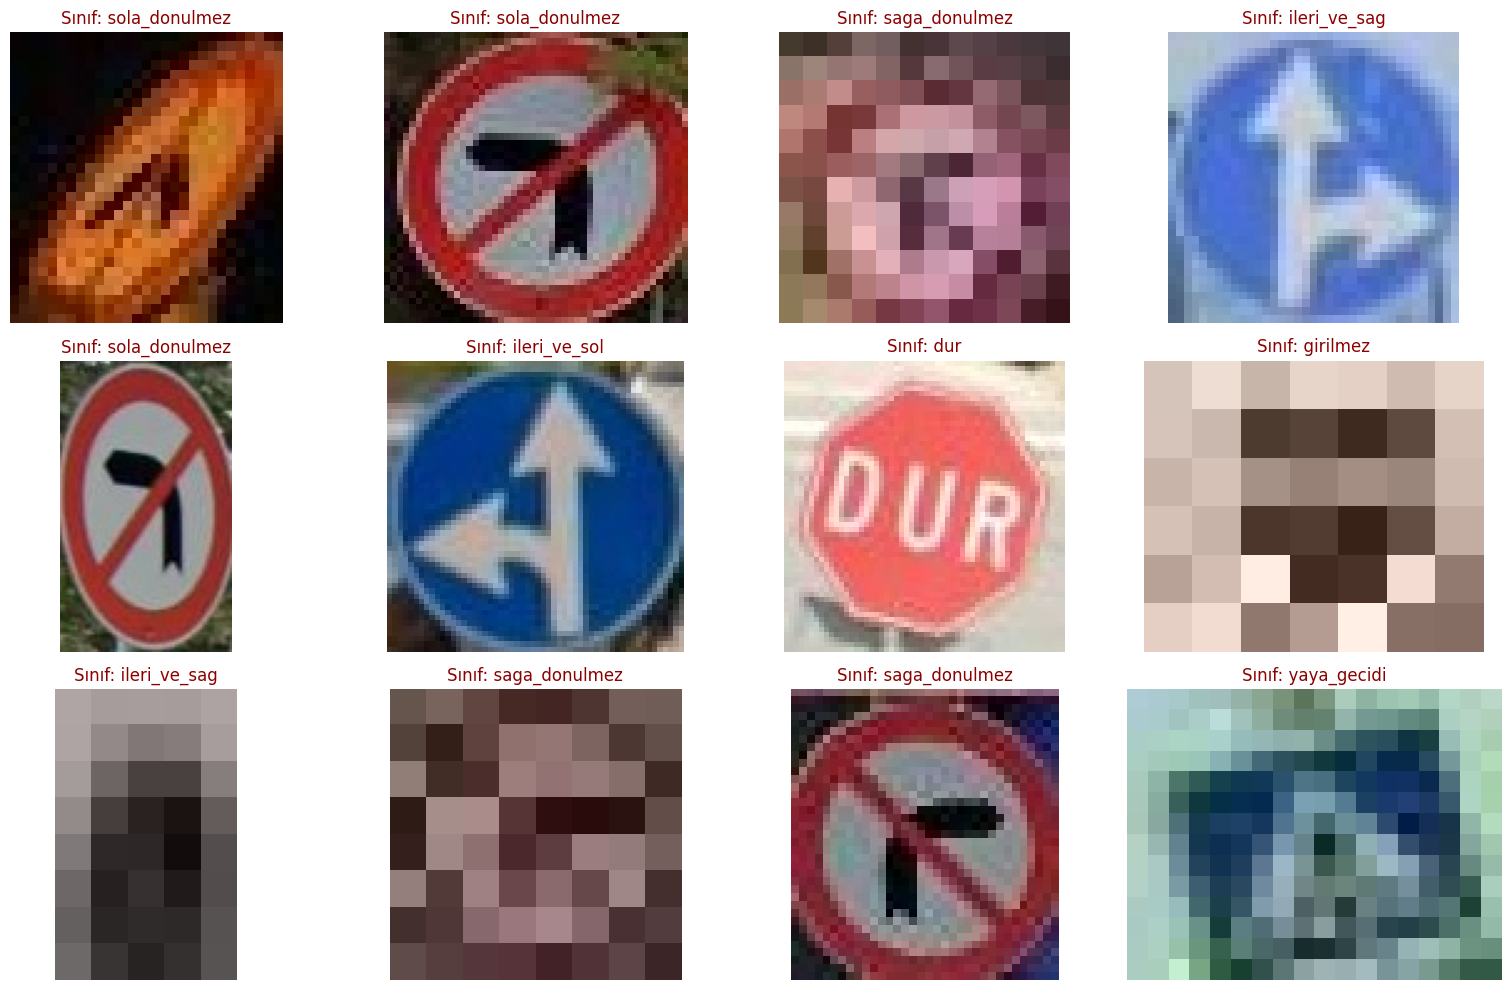

In [52]:
# ADIM 10: Kırpılmış Trafik Levhalarının Görsel Kalite Kontrolü ve Rastgele Örnekleme
import matplotlib.pyplot as plt
import cv2
import random
import os


GORSAL_DATA_DIR = "/content/cls_data_10_stratified/train"

def verileri_goster(ana_klasor, adet=12):
    if not os.path.exists(ana_klasor):
        print(f"Hata: {ana_klasor} yolu bulunamadı!")
        return


    siniflar = [d for d in os.listdir(ana_klasor) if os.path.isdir(os.path.join(ana_klasor, d))]

    tum_resimler = []
    for secili_sinif in siniflar:
        sinif_yolu = os.path.join(ana_klasor, secili_sinif)
        resimler = [os.path.join(sinif_yolu, img) for img in os.listdir(sinif_yolu)
                    if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
        for img_yolu in resimler:
            tum_resimler.append((img_yolu, secili_sinif))

    if not tum_resimler:
        print("Görselleştirilecek resim bulunamadı.")
        return


    secilenler = random.sample(tum_resimler, min(adet, len(tum_resimler)))


    plt.figure(figsize=(16, 10))
    for i, (yol, etiket) in enumerate(secilenler):
        img = cv2.imread(yol)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"Sınıf: {etiket}", color='darkred', fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


verileri_goster(GORSAL_DATA_DIR)

Bu kod, veri hazırlama sürecinin nihai raporunu oluşturur. Bir önceki adımda yaptığımız katmanlı bölme (stratified split) işleminin sonuçlarını matematiksel olarak doğrular.

In [29]:
# ADIM 11: Stratified (Katmanlı) Bölme Sonrası Veri Dağılımının Tablo ve Liste Halinde Raporlanması
import os
import pandas as pd

DATA_DIR = "/content/cls_data_10_stratified"
splits = ["train", "valid", "test"]

def count_images(folder):
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    return sum(1 for f in os.listdir(folder) if f.lower().endswith(exts))

rows = []
for sp in splits:
    sp_dir = os.path.join(DATA_DIR, sp)
    classes = sorted([d for d in os.listdir(sp_dir) if os.path.isdir(os.path.join(sp_dir, d))])
    for i, cls in enumerate(classes, start=1):
        n = count_images(os.path.join(sp_dir, cls))
        rows.append({"split": sp, "ID": i, "Sınıf İsmi": cls.replace("_", " ").title(), "Görüntü Sayısı": n})

df_counts = pd.DataFrame(rows)


for sp in splits:
    tmp = df_counts[df_counts["split"] == sp].copy()
    print(f"\n--- {sp.upper()} VERİ SETİ DAĞILIMI ---")
    print(f"{'ID':<4} | {'Sınıf İsmi':<22} | {'Görüntü Sayısı':>13}")
    print("-"*50)
    for _, r in tmp.iterrows():
        print(f"{int(r['ID']):<4} | {r['Sınıf İsmi']:<22} | {int(r['Görüntü Sayısı']):>13}")
    print("-"*50)
    print("TOPLAM GÖRÜNTÜ SAYISI:", int(tmp["Görüntü Sayısı"].sum()))

display(df_counts)



--- TRAIN VERİ SETİ DAĞILIMI ---
ID   | Sınıf İsmi             | Görüntü Sayısı
--------------------------------------------------
1    | Dur                    |           488
2    | Durak                  |           418
3    | Girilmez               |           274
4    | Girisi Olmayan Yol     |           146
5    | Ileri Ve Sag           |           498
6    | Ileri Ve Sol           |           499
7    | Park Yasak             |           122
8    | Saga Donulmez          |           510
9    | Sola Donulmez          |           578
10   | Yaya Gecidi            |           602
--------------------------------------------------
TOPLAM GÖRÜNTÜ SAYISI: 4135

--- VALID VERİ SETİ DAĞILIMI ---
ID   | Sınıf İsmi             | Görüntü Sayısı
--------------------------------------------------
1    | Dur                    |            61
2    | Durak                  |            52
3    | Girilmez               |            35
4    | Girisi Olmayan Yol     |            19
5    | Ileri 

,split,ID,Sınıf İsmi,Görüntü Sayısı
0,train,1,Dur,488
1,train,2,Durak,418
2,train,3,Girilmez,274
3,train,4,Girisi Olmayan Yol,146
4,train,5,Ileri Ve Sag,498
5,train,6,Ileri Ve Sol,499
6,train,7,Park Yasak,122
7,train,8,Saga Donulmez,510
8,train,9,Sola Donulmez,578
9,train,10,Yaya Gecidi,602


Bu kod, tablolardaki sayısal verileri görsel bir hikayeye dönüştürür. Modelin eğitimi üzerinde doğrudan etkisi olan "veri dengesi" durumunu bir bakışta anlamamızı sağlar.

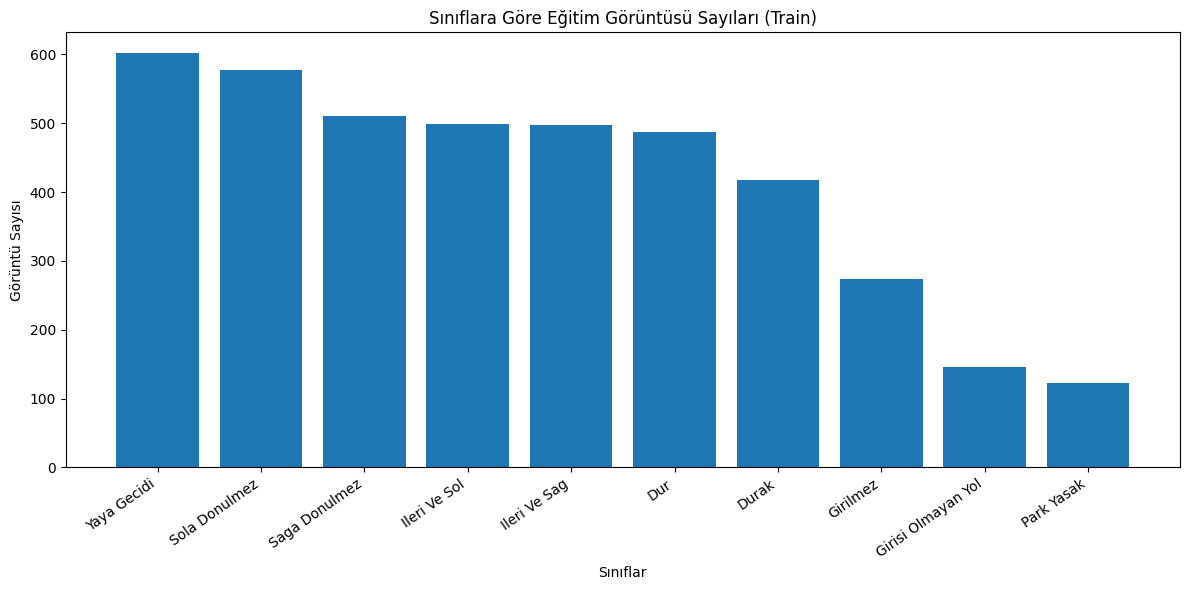

In [30]:
# ADIM 12: Eğitim Veri Seti Dağılımının Grafiksel Analizi (Bar Chart)
import matplotlib.pyplot as plt

df_train = df_counts[df_counts["split"]=="train"].sort_values("Görüntü Sayısı", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(df_train["Sınıf İsmi"], df_train["Görüntü Sayısı"])
plt.title("Sınıflara Göre Eğitim Görüntüsü Sayıları (Train)")
plt.xlabel("Sınıflar")
plt.ylabel("Görüntü Sayısı")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


Veri setinin tüm katmanlarını aynı anda görmemizi sağlayan son bir kıyaslama grafiğine bakıyoruz.

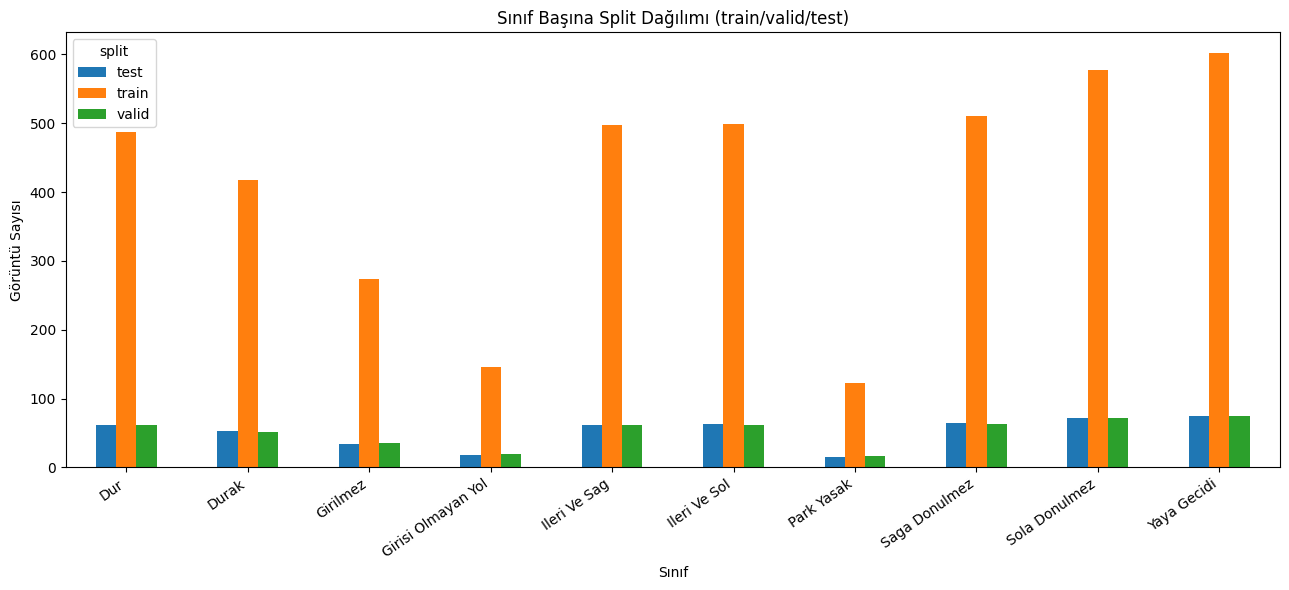

In [31]:
# ADIM 13: Sınıf Başına Küme Dağılımının (Train/Val/Test) Karşılaştırmalı Görselleştirmesi
pivot = df_counts.pivot_table(index="Sınıf İsmi", columns="split", values="Görüntü Sayısı", aggfunc="sum").fillna(0)
pivot = pivot.loc[sorted(pivot.index)]

pivot.plot(kind="bar", figsize=(13,6))
plt.title("Sınıf Başına Split Dağılımı (train/valid/test)")
plt.xlabel("Sınıf")
plt.ylabel("Görüntü Sayısı")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


CNN temelli eğitim sürecine geçiyoruz. burada yaptıklarımız kısaca:

Stratified olarak hazırlanmış classification verisi (cls_data_10_stratified) ImageFolder + DataLoader ile okunur; eğitim için veri artırma (rotation, color jitter), valid/test için sadece resize uygulanır.

MobileNetV2 ön-eğitimli ağı yüklenir, son classifier katmanı sınıf sayısına göre değiştirilir ve tüm model transfer learning ile eğitilir.

Eğitim döngüsünde her epoch’ta train/valid loss ve accuracy hesaplanır; en iyi validation accuracy elde edildiğinde model kaydedilir.

Eğitim tamamlandıktan sonra en iyi checkpoint yüklenir ve test seti üzerinde tahminler alınır.

Sonuçlar classification report, macro-F1 ve confusion matrix ile değerlendirilir.

DATA_DIR exists? True
Device: cuda
Classes: ['dur', 'durak', 'girilmez', 'girisi_olmayan_yol', 'ileri_ve_sag', 'ileri_ve_sol', 'park_yasak', 'saga_donulmez', 'sola_donulmez', 'yaya_gecidi']


Epoch 1/20 [valid]: 100%|██████████| 17/17 [00:01<00:00, 16.04it/s]


Epoch 1: train_loss=0.4229 train_acc=0.8590 val_loss=0.1848 val_acc=0.9284
✅ saved best


Epoch 2/20 [valid]: 100%|██████████| 17/17 [00:02<00:00,  7.25it/s]


Epoch 2: train_loss=0.1443 train_acc=0.9545 val_loss=0.0983 val_acc=0.9632
✅ saved best


...

Epoch 19: train_loss=0.0302 train_acc=0.9903 val_loss=0.0718 val_acc=0.9768


Epoch 20/20 [valid]: 100%|██████████| 17/17 [00:01<00:00, 15.74it/s]


Epoch 20: train_loss=0.0233 train_acc=0.9930 val_loss=0.1095 val_acc=0.9710
CNN Eğitim Süresi: 418.74 saniye


[test]: 100%|██████████| 17/17 [00:01<00:00, 15.89it/s]


                    precision    recall  f1-score   support

               dur     1.0000    1.0000    1.0000        61
             durak     1.0000    1.0000    1.0000        53
          girilmez     0.8919    0.9706    0.9296        34
girisi_olmayan_yol     1.0000    0.9444    0.9714        18
      ileri_ve_sag     0.9677    0.9677    0.9677        62
      ileri_ve_sol     1.0000    1.0000    1.0000        63
        park_yasak     0.9375    1.0000    0.9677        15
     saga_donulmez     0.9841    0.9688    0.9764        64
     sola_donulmez     0.9857    0.9583    0.9718        72
       yaya_gecidi     0.9867    0.9867    0.9867        75

          accuracy                         0.9807       517
         macro avg     0.9754    0.9797    0.9771       517
      weighted avg     0.9813    0.9807    0.9808       517

Macro-F1: 0.9771


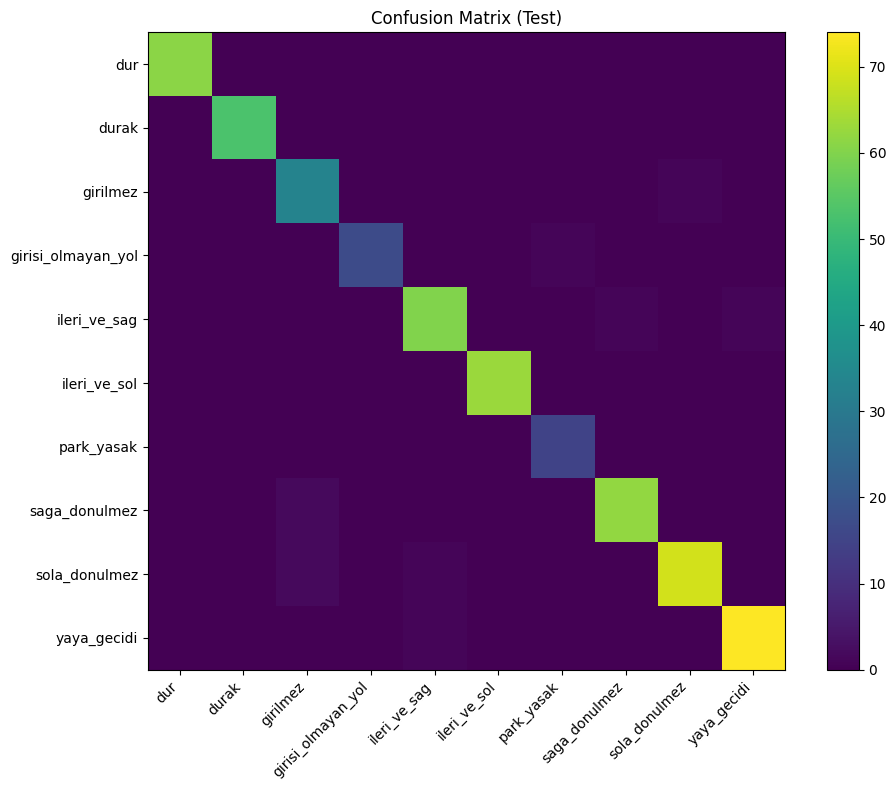

In [53]:
# ADIM 14: MobileNetV2(CNN) ile Transfer Learning: Model Eğitimi, Doğrulama ve Test Aşaması
import os

DATA_DIR = "/content/cls_data_10_stratified"  # stratified re-split sonrası yol
print("DATA_DIR exists?", os.path.exists(DATA_DIR))


import os, time, numpy as np
from tqdm import tqdm
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time

start_time = time.time()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "valid")
test_dir  = os.path.join(DATA_DIR, "test")

img_size=224
batch_size=32
epochs=20
lr=1e-3

train_tf = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

eval_tf = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
val_ds   = datasets.ImageFolder(val_dir, transform=eval_tf)
test_ds  = datasets.ImageFolder(test_dir, transform=eval_tf)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_val=0.0
best_path="/content/best_mobilenetv2.pt"

cnn_train_loss = []
cnn_train_acc  = []
cnn_val_loss   = []
cnn_val_acc    = []


for ep in range(1, epochs+1):
    model.train()
    tr_loss=0.0; tr_correct=0; tr_total=0
    for x,y in tqdm(train_loader, desc=f"Epoch {ep}/{epochs} [train]"):
        x,y=x.to(device), y.to(device)
        optimizer.zero_grad()
        out=model(x)
        loss=criterion(out,y)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()*x.size(0)
        pred = out.argmax(1)
        tr_correct += (pred==y).sum().item()
        tr_total += y.size(0)

    tr_loss/=max(tr_total,1)
    tr_acc=tr_correct/max(tr_total,1)

    model.eval()
    v_loss=0.0; v_correct=0; v_total=0
    with torch.no_grad():
        for x,y in tqdm(val_loader, desc=f"Epoch {ep}/{epochs} [valid]"):
            x,y=x.to(device), y.to(device)
            out=model(x)
            loss = criterion(out, y)
            v_loss += loss.item()*x.size(0)

            pred=out.argmax(1)
            v_correct += (pred==y).sum().item()
            v_total += y.size(0)

    v_loss /= max(v_total, 1)
    v_acc   = v_correct/max(v_total,1)

    print(f"Epoch {ep}: train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} val_loss={v_loss:.4f} val_acc={v_acc:.4f}")


    cnn_train_loss.append(tr_loss)
    cnn_train_acc.append(tr_acc)
    cnn_val_loss.append(v_loss)
    cnn_val_acc.append(v_acc)

    if v_acc>best_val:
        best_val=v_acc
        torch.save({"model":model.state_dict(),"classes":class_names}, best_path)
        print("✅ saved best")

end_time = time.time()
cnn_train_time_sec = end_time - start_time
print(f"CNN Eğitim Süresi: {cnn_train_time_sec:.2f} saniye")


ckpt=torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

y_true=[]; y_pred=[]
with torch.no_grad():
    for x,y in tqdm(test_loader, desc="[test]"):
        x=x.to(device)
        out=model(x)
        pred=out.argmax(1).cpu().numpy().tolist()
        y_pred += pred
        y_true += y.numpy().tolist()

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
print("Macro-F1:", round(f1_score(y_true, y_pred, average="macro"), 4))

cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Test)")
plt.colorbar()
ticks=np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)
plt.tight_layout()
plt.show()


Sırada eğitim boyunca her epoch sonunda kaydettiğimiz verileri görselleştirerek modelin nasıl öğrendiğini gösteren grafiklerimiz var.

Loss grafiği:
train_loss düşüşte yaklaşık 0.42 -> 0.03
val_loss ilk başta düşüşte sonra dalgalanma var.
Model öğreniyor fakat bir yerden sonra trainde iyileşmeye devam ederken
validation tarafı aynı hızda iyileşmiyor yani hafif overfitting var.

Accuracy grafiği:
Eğitim ve doğrulama doğruluk oranları birbirine paralel şekilde artmıştır.
Transfer learning kullandığımız için model, çok erken epochlarda (henüz 3-4.
epochta) %90 üzeri başarıya ulaşmıştır.


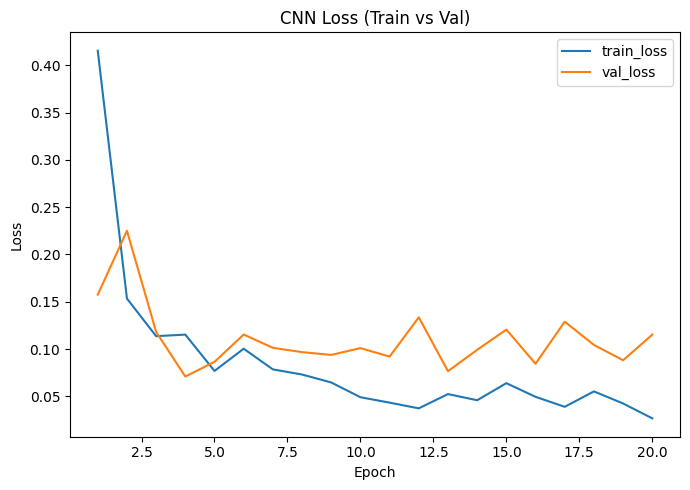

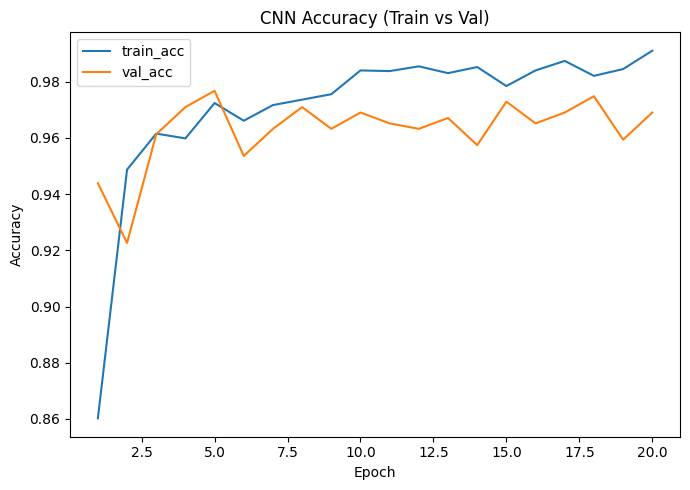

In [33]:
# ADIM 15: CNN Eğitim Sürecinin Analizi: Kayıp (Loss) ve Doğruluk (Accuracy) Grafiklerinin Çizilmesi
import numpy as np
import matplotlib.pyplot as plt

e = np.arange(1, len(cnn_train_loss)+1)

plt.figure(figsize=(7,5))
plt.plot(e, cnn_train_loss, label="train_loss")
plt.plot(e, cnn_val_loss, label="val_loss")
plt.title("CNN Loss (Train vs Val)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(e, cnn_train_acc, label="train_acc")
plt.plot(e, cnn_val_acc, label="val_acc")
plt.title("CNN Accuracy (Train vs Val)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


Sırada XGBoost eğitimine veri hazırlığı yapılıyor. burada  kod özetle şunu yapıyor:

Stratified klasör yapısından (train/valid/test) tüm görselleri ve sınıf etiketlerini toplayıp sınıf listesini (classes) çıkarıyor.

Her görseli 16×16 RGB’ye küçültüp [0,1] aralığına normalize ederek tek boyutlu vektöre (flatten) çeviriyor; böylece XGBoost’un tabular giriş formatına uygun hale getiriyor.

Sınıf adlarını sayısal etikete çevirmek için class_to_id haritası oluşturup X_train/y_train, X_val/y_val, X_test/y_test dizilerini dolduruyor.

Bu işlem pahalı olduğu için aynı boyutta tekrar tekrar hesaplamamak adına sonuçları .npz cache dosyasına kaydediyor; varsa cache’i direkt yükleyerek hızlandırıyor.

En sonda veri matrislerinin şekillerini ve sınıf isimlerini yazdırarak hazırlığın doğru olup olmadığını kontrol ediyor.

In [35]:
# ADIM 16: XGBoost Eğitimi İçin Veri Hazırlığı: Piksel Düzleştirme (Flattening) ve Önbellekleme (Caching)
import os, time, numpy as np
from PIL import Image

DATA_DIR = "/content/cls_data_10_stratified"
train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "valid")
test_dir  = os.path.join(DATA_DIR, "test")

IMG_SIZE = 16
CACHE = f"/content/pixels_cache_{IMG_SIZE}.npz"

def list_images_and_labels(split_dir):
    classes = sorted([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))])
    files, labels = [], []
    for cls in classes:
        cls_dir = os.path.join(split_dir, cls)
        for fn in os.listdir(cls_dir):
            if fn.lower().endswith((".jpg",".jpeg",".png")):
                files.append(os.path.join(cls_dir, fn))
                labels.append(cls)
    return files, labels, classes

def img_to_flat_pixels(path, img_size):
    img = Image.open(path).convert("RGB").resize((img_size, img_size))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr.reshape(-1)

def build_split(files, labels, class_to_id, img_size):
    X = np.zeros((len(files), img_size*img_size*3), dtype=np.float32)
    y = np.zeros((len(files),), dtype=np.int64)
    for i, (fp, lab) in enumerate(zip(files, labels)):
        X[i] = img_to_flat_pixels(fp, img_size)
        y[i] = class_to_id[lab]
    return X, y

if os.path.exists(CACHE):
    print("✅ Loaded cache:", CACHE)
    data = np.load(CACHE, allow_pickle=True)
    X_train, y_train = data["X_train"], data["y_train"]
    X_val,   y_val   = data["X_val"],   data["y_val"]
    X_test,  y_test  = data["X_test"],  data["y_test"]
    classes          = data["classes"].tolist()
else:
    print("⚙️ Cache not found, building once (this can take time)...")
    tr_files, tr_labels, classes = list_images_and_labels(train_dir)
    va_files, va_labels, _       = list_images_and_labels(val_dir)
    te_files, te_labels, _       = list_images_and_labels(test_dir)

    class_to_id = {c:i for i,c in enumerate(classes)}
    t0 = time.time()
    X_train, y_train = build_split(tr_files, tr_labels, class_to_id, IMG_SIZE)
    X_val,   y_val   = build_split(va_files, va_labels, class_to_id, IMG_SIZE)
    X_test,  y_test  = build_split(te_files, te_labels, class_to_id, IMG_SIZE)

    np.savez_compressed(CACHE,
                        X_train=X_train, y_train=y_train,
                        X_val=X_val, y_val=y_val,
                        X_test=X_test, y_test=y_test,
                        classes=np.array(classes, dtype=object))
    print("✅ Saved cache:", CACHE, "| built in", round(time.time()-t0, 2), "sec")

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Classes:", classes)


✅ Loaded cache: /content/pixels_cache_16.npz
Shapes: (4135, 768) (517, 768) (517, 768)
Classes: ['dur', 'durak', 'girilmez', 'girisi_olmayan_yol', 'ileri_ve_sag', 'ileri_ve_sol', 'park_yasak', 'saga_donulmez', 'sola_donulmez', 'yaya_gecidi']


Eğitim ise burada gerçekleşiyor:

xgboost kütüphanesini kurup, eğitim/valid verilerini XGBoost’un hızlı formatı olan DMatrix’e çeviriyoruz.

Problemi çok sınıflı sınıflandırma olarak ayarlayıp (multi:softprob), sınıf sayısını (num_class) ve takip edilecek metrikleri (mlogloss, merror) belirliyoruz.

Ağaçların karmaşıklığı ve genellemesi için max_depth, eta, subsample, colsample_bytree, min_child_weight, lambda gibi temel hiperparametreleri veriliyor.

Modeli en fazla 400 tur eğitirken early stopping ile valid performansı 30 tur iyileşmezse durdurup overfitting’i azaltıyor.

Eğitim süresini ve valid’e göre bulunan en iyi iterasyonu (best_iteration) yazdırarak eğitim özetini verdirtiyoruz.


In [37]:
# ADIM 17: Ağaç Temelli XGBoost Modelinin Eğitimi
!pip -q install xgboost

import time
import xgboost as xgb

num_classes = len(classes)

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)

params = {
    "objective": "multi:softprob",
    "num_class": num_classes,
    "eval_metric": ["mlogloss", "merror"],
    "max_depth": 4,
    "eta": 0.2,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 2,
    "lambda": 1.0,
    "tree_method": "hist",
    "seed": 42,
}

num_boost_round = 400
early_stopping_rounds = 30

evals_result = {}

t1 = time.time()
booster = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtrain, "train"), (dval, "valid")],
    early_stopping_rounds=early_stopping_rounds,
    evals_result=evals_result,
    verbose_eval=25
)
xgb_train_time = time.time() - t1

print("✅ XGBoost Train Time (sec):", round(xgb_train_time, 2))
print("Best iteration:", booster.best_iteration)


[0]	train-mlogloss:1.69533	train-merror:0.16227	valid-mlogloss:1.74475	valid-merror:0.25338
[25]	train-mlogloss:0.12585	train-merror:0.00774	valid-mlogloss:0.28844	valid-merror:0.07930
[50]	train-mlogloss:0.03271	train-merror:0.00000	valid-mlogloss:0.19369	valid-merror:0.06576
[75]	train-mlogloss:0.01499	train-merror:0.00000	valid-mlogloss:0.16763	valid-merror:0.06383
[88]	train-mlogloss:0.01144	train-merror:0.00000	valid-mlogloss:0.16227	valid-merror:0.05996
✅ XGBoost Train Time (sec): 36.87
Best iteration: 58


Burada XGBoost Loss grafiği ile XGBoost modelinin her bir iterasyonda (eklenen her yeni ağaçta) hatasını ne kadar azalttığını takip edebiliyoruz. 


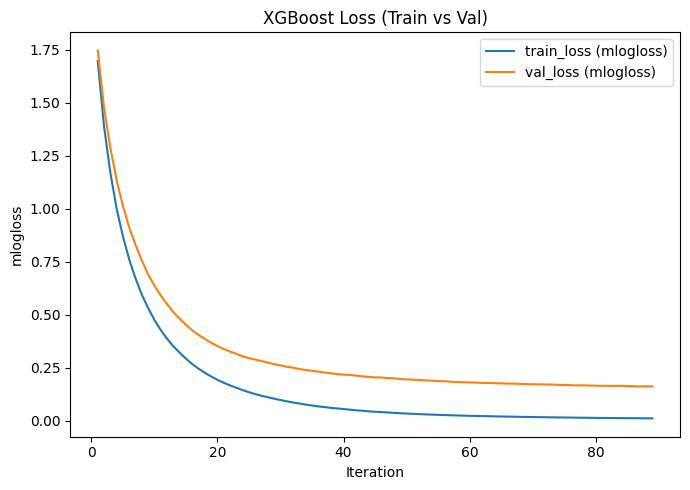

In [38]:
# ADIM 18: XGBoost Eğitim Sürecinin Analizi: Log-Loss (mlogloss) Eğrilerinin Çizilmesi
import numpy as np
import matplotlib.pyplot as plt

train_loss = evals_result["train"]["mlogloss"]
val_loss   = evals_result["valid"]["mlogloss"]
iters = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(7,5))
plt.plot(iters, train_loss, label="train_loss (mlogloss)")
plt.plot(iters, val_loss, label="val_loss (mlogloss)")
plt.title("XGBoost Loss (Train vs Val)")
plt.xlabel("Iteration")
plt.ylabel("mlogloss")
plt.legend()
plt.tight_layout()
plt.show()


XGBoost Accuracy Grafiği

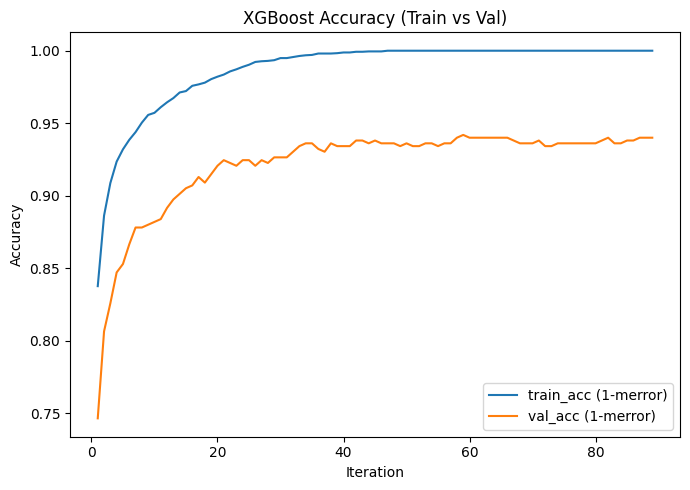

In [39]:
# ADIM 19: XGBoost Doğruluk (Accuracy) Gelişiminin İzlenmesi
train_err = evals_result["train"]["merror"]
val_err   = evals_result["valid"]["merror"]

train_acc = [1 - e for e in train_err]
val_acc   = [1 - e for e in val_err]
iters = np.arange(1, len(train_acc) + 1)

plt.figure(figsize=(7,5))
plt.plot(iters, train_acc, label="train_acc (1-merror)")
plt.plot(iters, val_acc, label="val_acc (1-merror)")
plt.title("XGBoost Accuracy (Train vs Val)")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


Grafiklerde görüldüğü üzere XGBoost, iterasyonlar ilerledikçe hatayı (logloss)
hızla sıfıra yaklaştırmıştır. Eğitim verisi üzerindeki başarı %100'e ulaşmıştır.
Doğrulama başarısı ise %95 civarındadır.

Bu kod, modelin tahmin gücünü farklı metriklerle detaylı bir şekilde raporlar.

XGBoost Test Accuracy: 0.9478
XGBoost Test Macro-F1: 0.9453

Report:
                     precision    recall  f1-score   support

               dur     1.0000    0.9836    0.9917        61
             durak     0.9804    0.9434    0.9615        53
          girilmez     0.9143    0.9412    0.9275        34
girisi_olmayan_yol     1.0000    0.9444    0.9714        18
      ileri_ve_sag     0.8676    0.9516    0.9077        62
      ileri_ve_sol     1.0000    0.9841    0.9920        63
        park_yasak     0.9286    0.8667    0.8966        15
     saga_donulmez     0.9091    0.9375    0.9231        64
     sola_donulmez     0.9286    0.9028    0.9155        72
       yaya_gecidi     0.9730    0.9600    0.9664        75

          accuracy                         0.9478       517
         macro avg     0.9502    0.9415    0.9453       517
      weighted avg     0.9493    0.9478    0.9481       517



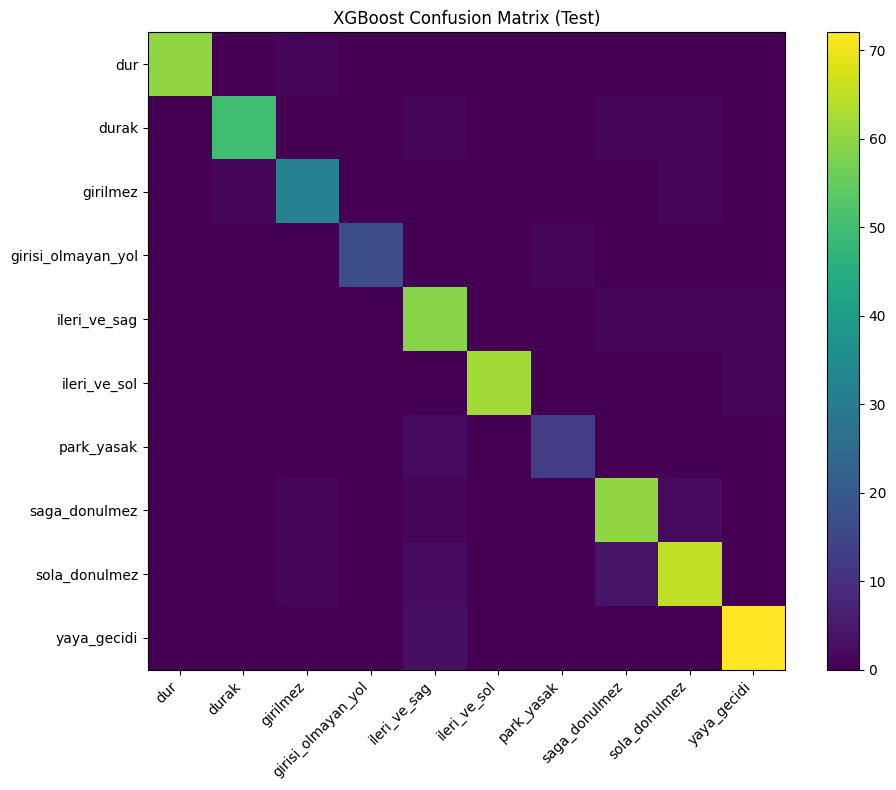

In [40]:
# ADIM 20: XGBoost Modelinin Test Seti Üzerinde Değerlendirilmesi ve Hata Matrisi Analizi
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import xgboost as xgb
import numpy as np

dtest = xgb.DMatrix(X_test, label=y_test)

proba = booster.predict(dtest)
pred = np.argmax(proba, axis=1)

acc = accuracy_score(y_test, pred)
macro_f1 = f1_score(y_test, pred, average="macro")
print("XGBoost Test Accuracy:", round(acc, 4))
print("XGBoost Test Macro-F1:", round(macro_f1, 4))
print("\nReport:\n", classification_report(y_test, pred, target_names=classes, digits=4))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation="nearest")
plt.title("XGBoost Confusion Matrix (Test)")
plt.colorbar()
ticks=np.arange(len(classes))
plt.xticks(ticks, classes, rotation=45, ha="right")
plt.yticks(ticks, classes)
plt.tight_layout()
plt.show()


Bu kod, CNN modelinin başarısını sadece accuracy üzerinden değil, daha hassas olan ROC-AUC metriği üzerinden analiz eder.

In [44]:
# ADIM 21: CNN Modelinin Gelişmiş Performans Metrikleri (ROC-AUC) ile Değerlendirilmesi
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize


cnn_test_acc = accuracy_score(y_true, y_pred)
cnn_test_f1  = f1_score(y_true, y_pred, average="macro")

model.eval()
proba_cnn = []
y_true_check = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        probs = torch.softmax(out, dim=1).cpu().numpy()
        proba_cnn.append(probs)
        y_true_check += y.numpy().tolist()

proba_cnn = np.vstack(proba_cnn)

# ROC-AUC (multiclass OvR)
num_classes = len(class_names)
y_bin_cnn = label_binarize(np.array(y_true_check), classes=list(range(num_classes)))
cnn_rocauc = roc_auc_score(y_bin_cnn, proba_cnn, average="macro", multi_class="ovr")

print("CNN Test Accuracy:", round(cnn_test_acc, 4))
print("CNN Test Macro-F1:", round(cnn_test_f1, 4))
print("CNN ROC-AUC OvR (macro):", round(cnn_rocauc, 4))


CNN Test Accuracy: 0.971
CNN Test Macro-F1: 0.9696
CNN ROC-AUC OvR (macro): 0.9992


Bu kod, ağaç temelli XGBoost modelinin başarısını sadece accuracy üzerinden değil, daha hassas olan ROC-AUC metriği üzerinden analiz eder.

In [46]:
# ADIM 22: XGBoost Modelinin Gelişmiş Performans Metrikleri (ROC-AUC) ile Ölçümü
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

xgb_test_acc = accuracy_score(y_test, pred)
xgb_test_f1  = f1_score(y_test, pred, average="macro")

y_bin_xgb = label_binarize(np.array(y_test), classes=list(range(len(classes))))
xgb_rocauc = roc_auc_score(y_bin_xgb, proba, average="macro", multi_class="ovr")

print("XGB Test Accuracy:", round(xgb_test_acc, 4))
print("XGB Test Macro-F1:", round(xgb_test_f1, 4))
print("XGB ROC-AUC OvR (macro):", round(xgb_rocauc, 4))


XGB Test Accuracy: 0.9478
XGB Test Macro-F1: 0.9453
XGB ROC-AUC OvR (macro): 0.9975


Bu kod, tüm deney sürecini tek bir özet tabloda ve grafik setinde birleştirir. Doğruluk (Accuracy), denge (F1), ayırt edicilik (ROC-AUC) ve verimlilik (Eğitim Süresi) metriklerini bir arada görüp karşılaştırma imkanı sunar. 

Kıyaslama Sonucu: MobileNetV2, görüntüdeki mekansal özellikleri öğrenir.
Karmaşık desenleri yakalar. Fakat eğitim süresi daha uzundur. XGBoos
ise daha hızlı, yorumlanabilirliği yüksektir fakat görüntüdeki mekansal
ilişkiyi kaybeder.


--- MODEL PERFORMANS ÖZETİ ---


,Model,Test Accuracy,Macro-F1,ROC-AUC,Train Time (sec)
0,CNN (MobileNetV2),0.970986,0.97710,0.999178,418.74
1,XGBoost (Raw Pixels),0.947776,0.94535,0.997542,36.87


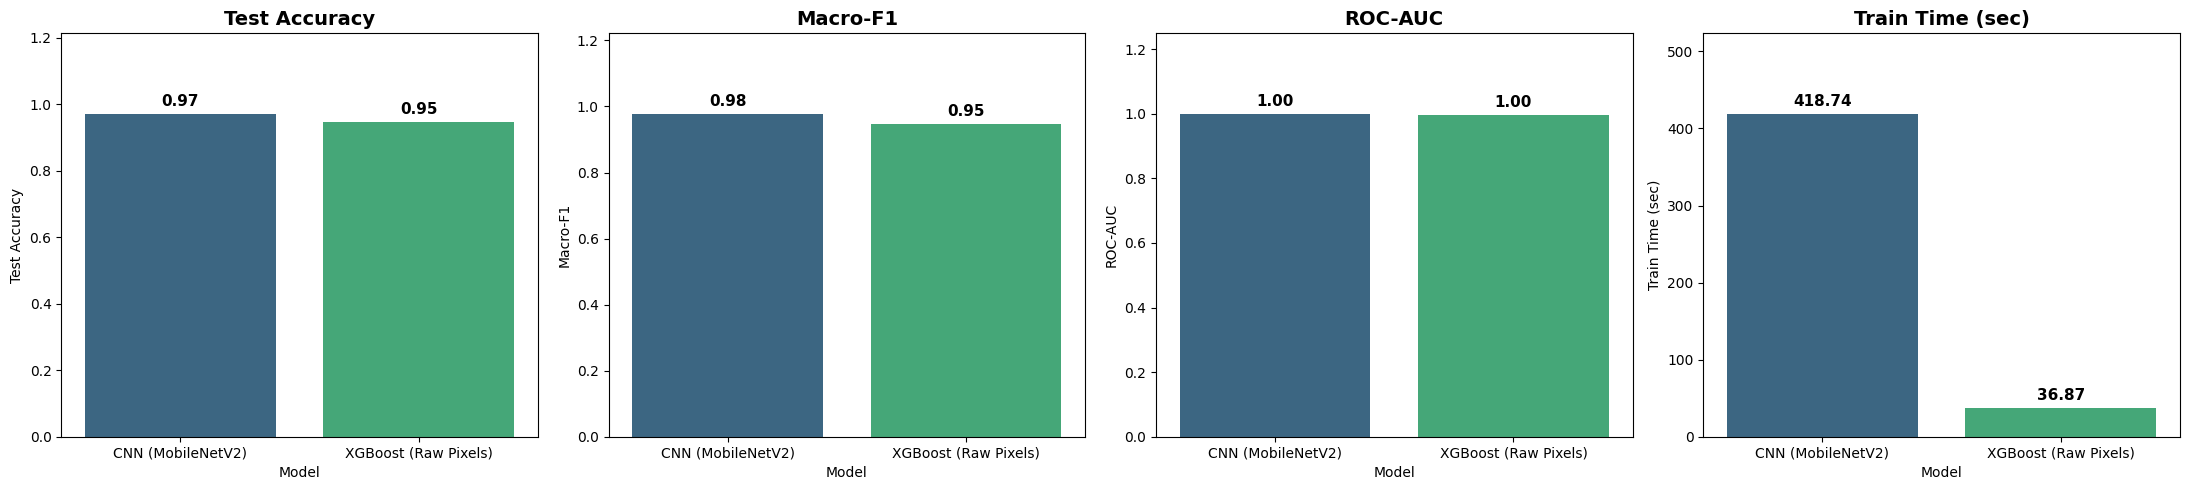

In [55]:
# ADIM 23: Final Karşılaştırma: CNN ve XGBoost Modellerinin Performans Analizi ve Görselleştirilmesi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Özet Tabloyu Oluşturma
summary = pd.DataFrame([
    {
        "Model": "CNN (MobileNetV2)",
        "Test Accuracy": cnn_test_acc if 'cnn_test_acc' in locals() else 0.0,
        "Macro-F1": round(f1_score(y_true, y_pred, average="macro"), 4) if 'y_true' in locals() else 0.0,
        "ROC-AUC": cnn_rocauc if 'cnn_rocauc' in locals() else 0.0,
        "Train Time (sec)": round(cnn_train_time_sec, 2) if 'cnn_train_time_sec' in locals() else 0.0
    },
    {
        "Model": "XGBoost (Raw Pixels)",
        "Test Accuracy": xgb_test_acc if 'xgb_test_acc' in locals() else 0.0,
        "Macro-F1": xgb_test_f1 if 'xgb_test_f1' in locals() else 0.0,
        "ROC-AUC": xgb_rocauc if 'xgb_rocauc' in locals() else 0.0,
        "Train Time (sec)": round(xgb_train_time, 2) if 'xgb_train_time' in locals() else 0.0
    }
])

print("\n--- MODEL PERFORMANS ÖZETİ ---")
display(summary)

# Grafiksel Karşılaştırma (4 metrik ile)
metrics = ["Test Accuracy", "Macro-F1", "ROC-AUC", "Train Time (sec)"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, metric in enumerate(metrics):

    sns.barplot(x="Model", y=metric, data=summary, ax=axes[i],
                palette="viridis", hue="Model", legend=False)

    axes[i].set_title(f"{metric}", fontsize=14, fontweight='bold')
    axes[i].set_ylim(0, summary[metric].max() * 1.25)


    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center', va = 'center',
                         xytext = (0, 9),
                         textcoords = 'offset points',
                         fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Doğruluk (Accuracy) & F1-Skor:

● MobileNetV2 (CNN): %97.09 başarı ile en yüksek performansı göstermiştir.
Görüntüdeki mekansal özellikleri (şekil, kenar) koruduğu için daha başarılıdır.

● XGBoost: %94.77 başarı ile CNN'i çok yakından takip etmiştir. Ham piksel
verisiyle çalışmasına rağmen bu kadar yüksek başarı elde etmesi, trafik
işaretlerinin renk ve form olarak çok belirgin özniteliklere sahip olduğunu
kanıtlar.

ROC-AUC Skoru:

● Her iki model de 1.00 ROC-AUC skoruna ulaşmıştır. Bu, modellerin sınıfları
(örneğin "Dur" ile "Girilmez" levhasını) birbirinden ayırma yeteneğinin iyi
olduğunu gösterir.

Eğitim Süresi (Train Time):

● Grafiğin sağ tarafında görüldüğü gibi; MobileNetV2'nin eğitimi GPU üzerinde
418 saniye sürerken, XGBoost sadece 36 saniyede eğitimi tamamlamıştır.

● Yorum: Eğer donanım kaynağımız sınırsızsa ve en yüksek doğruluk (güvenlik)
hedefleniyorsa MobileNetV2 seçilmelidir. Ancak çok düşük güçlü bir işlemcide
anlık sonuç isteniyorsa, %2'lik doğruluk kaybı göze alınarak 10 kat daha hızlı
olan XGBoost kullanılabilir.